In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage
import scipy.cluster.hierarchy as shc

pd.set_option('display.max_columns', None)

In [46]:
def loader(id):
    if id in ['id', 'user_id']:
        df = pd.read_csv(f'data/affinity_post_{id}.csv').set_index(id)
        for col in ['1_tipoEscula', '7_idiomas', '14_etapaEducativa', '15_segLengua', '16_primLengua']:
            df[col] = df[col].apply(lambda x: eval(x) if pd.notnull(x) else np.nan)
        return df
    else:
        print('Wrong id')
        return

In [47]:
df = loader('id') # PICK DATA user_id == 97.1% lossy compression (35.0x smaller), id == 88.5% lossless compression (8.7x smaller)

C:\Users\Alex\AppData\Local\Temp\ipykernel_27768\1188995697.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'data/affinity_post_{id}.csv').set_index(id)


In [48]:
# Join language answer columns into one

def handle_nan(value):
    if isinstance(value, float) and np.isnan(value): # check is instance because np.isnan() can only evaluate floats
        return []
    else:
        return value

def get_set_fromList(row_series, col):
    if row_series[col] == []:
        return np.nan
    if isinstance(row_series[col], list):
        return list(set(row_series[col]))
    else:
        return row_series[col]

df['7_idiomas'] = df['7_idiomas'].apply(lambda x: ['Español' if i == 'Bilingüe1' else i for i in x] if x == x else np.nan)
df['15_languages'] = df[['16_primLengua', '15_segLengua', '7_idiomas']].apply(lambda row: handle_nan(row['16_primLengua']) + handle_nan(row['15_segLengua']) + handle_nan(row['7_idiomas']), axis=1)
df['15_languages'] = df.apply(lambda row_series: get_set_fromList(row_series, '15_languages'), axis=1)

In [49]:
# Drop nas, drop old language columns, fix some values
df = df.dropna(subset=['5_extraescolares', '3_comedor', '2_religioso', '4_transporte', '1_tipoEscula', '9_precioComun', '11_hombre', '6_techImportancia', '8_resultAcademicosImportancia', '13_numHijos', '14_etapaEducativa', '15_languages'])

df.drop(['7_idiomas', '16_primLengua', '15_segLengua'], axis=1, inplace=True)

df['17_country'] = df['17_country'].replace('Maroc ⵍⵎⵖⵔⵉⴱ المغرب', 'Marruecos')
df['14_etapaEducativa'] = df['14_etapaEducativa'].replace('Otros1', 'Otros')
df.loc[df['12_edad'].isna(), '12_edad'] = 'Prefiero no decirlo1'
df.loc[df['17_iso3166'].isna(), '17_iso3166'] = 'Falta-ISO'
df.loc[df['19_paraCuando'].isna(), '19_paraCuando'] = 'NoRespondioParaCuando'

In [50]:
# # Save non-list images
# for column in ['2_religioso', '3_comedor', '4_transporte',
#        '5_extraescolares', '6_techImportancia',
#        '8_resultAcademicosImportancia', '9_precioMin', '9_precioComun',
#        '9_precioMax', '11_hombre', '12_edad', '13_numHijos',
#        '17_num_direcciones', '17_iso3166',
#        '18_distanciaMin', '18_distanciaComun', '18_distanciaMax',
#        '19_paraCuando']:
#     plt.figure()  # Create a new figure
#     df[column].hist(bins=np.arange(len(column))-.5, rwidth=0.8)  # Plot histogram
#     plt.title(f'Histogram of {column}')  # Set title
#     if column in ['17_iso3166', '12_edad', '19_paraCuando']:
#         plt.xticks(rotation=90)
#     else:
#         plt.xticks(rotation=0)
#     plt.xlabel(column)  # Set x-axis label
#     plt.ylabel('Frequency')  # Set y-axis label
#     plt.tight_layout()
#     plt.savefig(f'assets/{column}_histogram.png')  # Save the figure
#     plt.close()

### Create dummies

In [51]:
# Create dummy columns
df_preped = df.copy()
for col in ['1_tipoEscula', '14_etapaEducativa', '15_languages']:
    df_preped[col] = df_preped[col].apply(lambda x: ','.join(x)) # Turn into a string to get dummies
    dummies = df_preped[col].str.get_dummies(',')
    prefix = col.split('_')[0]
    dummies = dummies.add_prefix(f'{prefix}_')
    df_preped = pd.concat([df_preped, dummies], axis=1)

for col in ['12_edad', '19_paraCuando']:
# for col in ['12_edad', '19_paraCuando', '17_country']:
# for col in ['12_edad', '19_paraCuando', '17_iso3166']:
# for col in ['12_edad','19_paraCuando', '17_country', '17_iso3166']:   # Exclude country to avoid perfect colinearity with iso3166
    dummies = pd.get_dummies(df_preped[col]).astype(int)
    prefix = col.split('_')[0]
    dummies = dummies.add_prefix(f'{prefix}_')
    df_preped = pd.concat([df_preped, dummies], axis=1)

In [52]:
## Drop dummy-source columns and colinear features

# df_preped = df_preped.drop(['1_tipoEscula', '12_edad', '14_etapaEducativa', '15_languages', '17_iso3166', '19_paraCuando', '9_precioMin', '9_precioMax', '18_distanciaMin', '18_distanciaMax', '19_Solo estoy curioseando1', '17_country', '12_Prefiero no decirlo1', '1_Indiferente1', '17_Falta-ISO'], axis=1)
df_preped = df_preped.drop(['1_tipoEscula', '12_edad', '14_etapaEducativa', '15_languages', '17_iso3166', '19_paraCuando', '9_precioMin', '9_precioMax', '18_distanciaMin', '18_distanciaMax', '19_Solo estoy curioseando1', '17_country', '12_Prefiero no decirlo1', '1_Indiferente1'], axis=1)

In [53]:
# Drop na instead of impute
df_preped = df_preped.dropna(subset=['18_distanciaComun'])

In [54]:
# # Fill missing with SimpleImputer stat=median
# imputer = SimpleImputer(missing_values=np.nan, strategy='median')  # Use 5 nearest neighbors
# df_imputed = imputer.fit_transform(df_preped)
# df_preped = pd.DataFrame(df_imputed, columns=df_preped.columns)

In [55]:
# # Save list imagess
# columns = ['14_Ed. Infantil 1er ciclo (0-3 años)', '14_Ed. Infantil 2° ciclo (3-6 años)', '14_Primaria', '14_Secundaria', '14_Bachillerato', '14_Otros1']
# data = [df_preped[col].sum() for col in columns]
# fig, ax = plt.subplots()
# ax.bar(columns, data)
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.savefig(f'assets/14_etapas_histogram.png')  # Save the figure

# columns = ['1_Privado', '1_Concertado', '1_Público']
# data = [df_preped[col].sum() for col in columns]
# fig, ax = plt.subplots()
# ax.bar(columns, data)
# plt.tight_layout()
# plt.savefig(f'assets/1_type_histogram.png')  # Save the figure

# columns = ['15_Español', '15_Inglés',  '15_Alemán', '15_Catalán', '15_Francés', '15_Chino', 
#         '15_Portugués', '15_Gallego', '15_Italiano', '15_Euskera', 
#         '15_Valenciano']
# data = [df_preped[col].sum() for col in columns]
# fig, ax = plt.subplots()
# ax.bar(columns, data)
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.savefig(f'assets/15_languages_histogram.png')  # Save the figure


In [56]:
# # Check colinearity with VIF == 15 minutes for id, 3 minutes for user_id
# # drop non-numeric columns if any
# numeric_cols = df_preped.select_dtypes(include=[np.number])

# # For each column, calculate VIF
# vif = pd.DataFrame()
# vif["variables"] = numeric_cols.columns
# vif["VIF"] = [variance_inflation_factor(numeric_cols.values, i) for i in range(numeric_cols.shape[1])]

# pd.set_option('display.max_rows', None)
# vif.sort_values(by='VIF', ascending=False)

### Clustering prep Scaling, PCA, etc

In [57]:
# Scale columns
scaler = StandardScaler(with_std=True,
                        with_mean=True)
df_scaled = scaler.fit_transform(df_preped)
df_scaled = pd.DataFrame(df_scaled)
# df_normalized = normalize(df_scaled)
# df_normalized = pd.DataFrame(df_normalized)

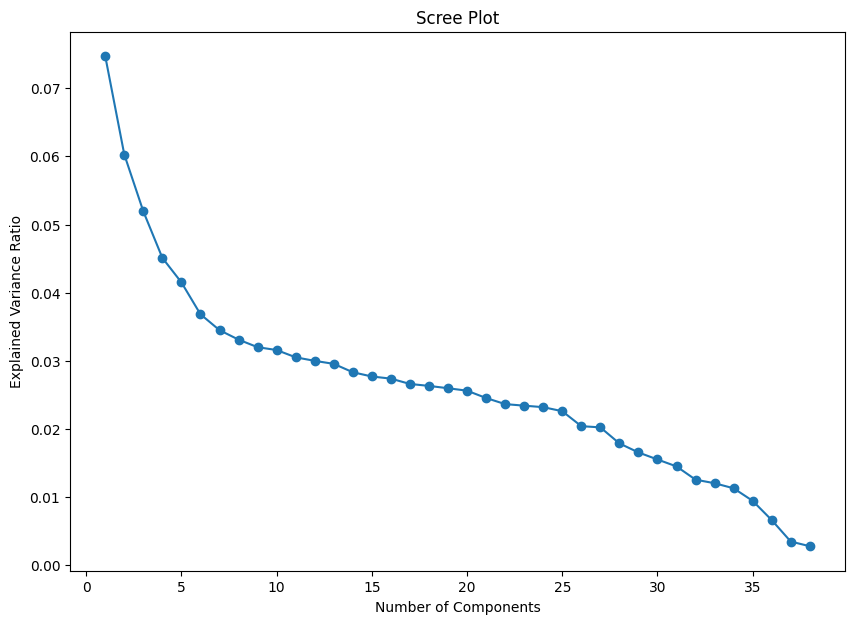

In [58]:
# Get a scree plot for all principal components
pca = PCA()
df_pca = pca.fit_transform(df_scaled)

# Calculate explained variance ratios
explained_variance_ratio = pca.explained_variance_ratio_

# Create scree plot
plt.figure(figsize=(10, 7))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.savefig(f'assets/scree_plot.png')  # Save the figure
# plt.show()

In [59]:
# Calculate feature loadings
pca = PCA(n_components=5) #41-46 for users
df_pca = pca.fit_transform(df_scaled)
# df_pca = pd.DataFrame(df_pca)

explained_variance_ratio = pca.explained_variance_ratio_
loadings = pca.components_
df_loadings = pd.DataFrame()

for i, loading in enumerate(loadings):
    pc_loading_raw = {}
    pc_loading = {}
    for j, feature_loading in enumerate(loading):
        pc_loading_raw[df_preped.columns[j]] = round(feature_loading, 1)
        pc_loading[df_preped.columns[j]] = (feature_loading**2)
    df_loadings[i] = pc_loading
    df_loadings[f'{i}_raw'] = pc_loading_raw
    df_loadings[i] = round(np.sqrt(df_loadings[i] * 1000000), 2)


In [60]:
explained_variance_ratio
# Id
## array([0.02069205, 0.01757245, 0.01630872, 0.01349931, 0.01341315]) iso
## array([0.04659083, 0.03971806, 0.03267019, 0.02451382, 0.02266225]) country
## array([0.07468831, 0.06026025, 0.05178502, 0.04487834, 0.0407448 ]) neither

# User
## array([0.04975995, 0.03750156, 0.03354906, 0.03212832, 0.03153266])
## array([0.06788936, 0.05136569, 0.04662679, 0.03984737, 0.03679592])
## array([0.0767979 , 0.05826753, 0.04523892, 0.04193422, 0.03855237])

array([0.07466616, 0.06023591, 0.05185204, 0.0443826 , 0.04127562])

# 1 Ciudad grande Madrid
+ Bachellerato 
+ Secundario
+ Precio
+ Privado
+ Primaria
+ religioso
+ Madrid
- No este ano
+ privado
+ Etapa 2
- Publico 

# 2 Joven
+ Entre 30-40
+ Etapa 2
- Menos de 40
+ Infantil
+ Primaria
+ Comedor
+ Extra escolares
- Hijos
- menos de 30
- Distancia
+ Pais Vasco
+ Valencia

# 3 Afuera de ciudad
+ Euskera
+ Pais Vasco
+ Catalan
+ Catalonia
- Madrid
- Frances
- Este ano
- Ano que viene
- Pueblo



In [66]:
# Show feature loadings
pd.set_option('display.max_rows', 30)

df_loadings.sort_values(by=1, ascending=False).head(30)#.to_csv(f'assets/principal_components.csv', index=False)


,0,0_raw,1,1_raw,2,2_raw,3,3_raw,4,4_raw
12_Entre 30 y 40,46.94,0.0,477.20,-0.5,18.03,-0.0,135.49,0.1,262.00,0.3
14_Ed. Infantil 2° ciclo (3-6 años),192.57,0.2,406.89,-0.4,55.40,0.1,23.69,-0.0,101.17,-0.1
12_Más de 40,33.89,-0.0,355.18,0.4,145.27,-0.1,86.52,-0.1,387.78,-0.4
14_Primaria,252.92,0.3,313.11,-0.3,37.99,0.0,20.54,-0.0,208.98,-0.2
3_comedor,190.50,0.2,282.24,-0.3,153.00,-0.2,113.63,-0.1,116.24,-0.1
5_extraescolares,239.02,0.2,205.73,-0.2,57.33,-0.1,202.07,-0.2,199.82,-0.2
18_distanciaComun,140.41,0.1,187.14,0.2,27.86,-0.0,108.63,0.1,284.51,0.3
14_Bachillerato,362.15,0.4,179.52,0.2,33.61,-0.0,14.47,-0.0,0.17,0.0
13_numHijos,46.46,0.0,168.58,0.2,11.28,-0.0,43.74,-0.0,141.61,-0.1
9_precioComun,255.74,0.3,154.59,0.2,68.12,-0.1,122.99,0.1,272.20,0.3


In [156]:
# # check cluster SSE
# sse = []
# list_k = list(range(1, 30))

# for k in list_k:
#     km = KMeans(n_clusters=k)
#     km.fit(df_pca)
#     sse.append(km.inertia_)

# # Plot sse against k
# plt.figure(figsize=(6, 6))
# plt.plot(list_k, sse, '-o')
# plt.xlabel('Number of clusters k')
# plt.ylabel('Sum of squared distance')

In [157]:
# Create cluster
kmeans = KMeans(n_clusters=5, random_state=42) 
k3_pca_3 = kmeans.fit(df_pca)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
# np.round(centroids, 4)

c:\Users\Alex\Documents\testing\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [158]:
x = 0
y = 1
z = 2

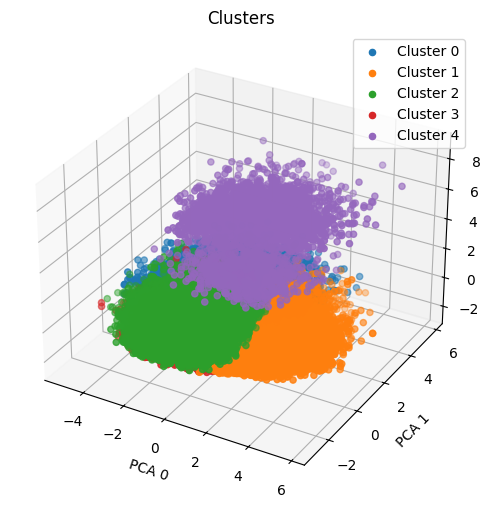

In [159]:
# Plot 3d
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Assuming that df_pca is a 3D array for simplicity
for i in range(k3_pca_3.n_clusters):
    ax.scatter(df_pca[labels == i, x], df_pca[labels == i, y], df_pca[labels == i, z], label='Cluster {}'.format(i))

ax.set_title('Clusters')
ax.set_xlabel(f'PCA {x}')
ax.set_ylabel(f'PCA {y}')
ax.set_zlabel(f'PCA {z}')
ax.legend()
plt.show()

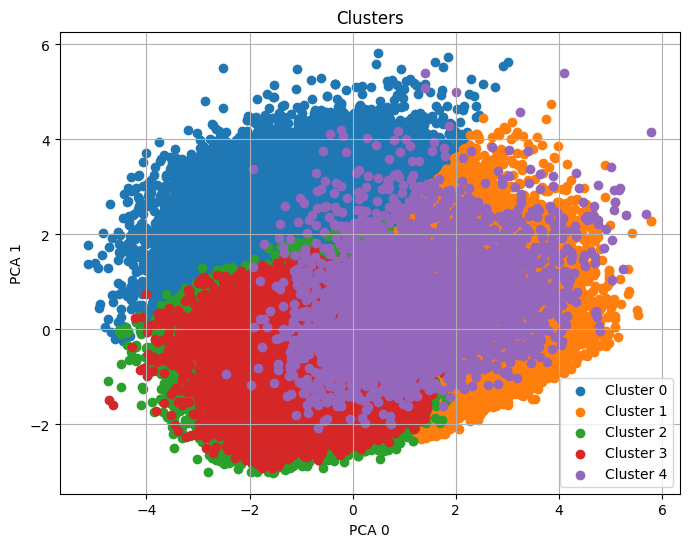

In [160]:
# Assuming that df_pca is a 2D array for simplicity
plt.figure(figsize=(8, 6))

x = 0
y = 1

# Scatter plot of the data points
for i in range(k3_pca_3.n_clusters):
    plt.scatter(df_pca[labels == i, x], df_pca[labels == i, y], label='Cluster {}'.format(i))

# # Plotting centroids
# plt.scatter(centroids[:, 1], centroids[:, 1], s=300, c='red', label='Centroids')

plt.title('Clusters')
plt.xlabel(f'PCA {x}')
plt.ylabel(f'PCA {y}')
plt.legend()
plt.grid(True)
plt.show()


In [161]:
import plotly.graph_objects as go
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Assuming df_pca is a pandas DataFrame and labels is a numpy array
df_pca['labels'] = labels

# Create dropdown for selecting dimensions
dims = df_pca.columns.tolist()
x_dropdown = widgets.Dropdown(options=dims, description='X:')
y_dropdown = widgets.Dropdown(options=dims, description='Y:')
z_dropdown = widgets.Dropdown(options=dims, description='Z:')
display(x_dropdown, y_dropdown, z_dropdown)

def update_plot(x, y, z):
    # Create a trace for each cluster
    traces = []
    for i in df_pca['labels'].unique():
        df_cluster = df_pca[df_pca['labels'] == i]
        traces.append(go.Scatter3d(
            x=df_cluster[x],  # replace with your column name
            y=df_cluster[y],  # replace with your column name
            z=df_cluster[z],  # replace with your column name
            mode='markers',
            marker=dict(
                size=3,
                line=dict(
                    color='rgba(217, 217, 217, 0.14)',
                    width=0.5
                ),
                opacity=0.8
            ),
            name=f'Cluster {i}'
        ))

    layout = go.Layout(
        margin=dict(
            l=0,
            r=0,
            b=0,
            t=0
        )
    )

    fig = go.Figure(data=traces, layout=layout)
    fig.show()

# Update the plot whenever the value of the dropdowns changes
widgets.interactive(update_plot, x=x_dropdown, y=y_dropdown, z=z_dropdown)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
centroids # Rich city older religious users, men and women  # Cheap urgent middle-aged women with few young kids  # Middle class older women with several teenage/young kids

array([[ 0.32786521, -2.05801958,  0.17397337, -0.02940851,  0.19380151],
       [-0.59819994,  0.76560235, -0.8559567 , -1.25794416,  0.27942439],
       [-0.55776146,  1.09574213,  2.25083398,  0.18448673,  0.29347918],
       [ 8.15933908,  2.11745614, -0.33424696,  0.04118535, -0.19944505],
       [-0.54252569,  0.32076471, -0.79384723,  1.16143746, -0.65058894]])

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Compute the correlation-based distance matrix
corr_dist = pdist(df_pca, metric='correlation')

# Perform hierarchical clustering using the correlation-based distance matrix
linkage_matrix = linkage(corr_dist, method='complete')

# Plot the dendrogram
dendrogram(linkage_matrix)
plt.show()

In [ ]:
# plt.figure(figsize =(8, 8))
# plt.title('Visualising the data')
# Dendrogram = shc.dendrogram((shc.linkage(data_principal, method ='ward')))

In [ ]:
# HClust = AgglomerativeClustering
# hc_comp = HClust(distance_threshold=0,
#                  n_clusters=None,
#                  linkage='complete')
# hc_comp.fit(df_normalized)


In [ ]:
# hc_cor = HClust(distance_threshold=0,
#                 n_clusters=None,
#                 linkage='average');
# hc_cor.fit(df_scaled)

In [ ]:
# cargs = {'color_threshold':-np.inf,
#          'above_threshold_color':'black'}
# linkage_comp = compute_linkage(hc_comp)
# fig, ax = plt.subplots(1, 1, figsize=(80, 80))
# dendrogram(linkage_comp,
#            ax=ax,
#            **cargs);


In [ ]:
# fig, ax = plt.subplots(1, 1, figsize=(80, 80))
# dendrogram(linkage_comp,
#            ax=ax,
#            color_threshold=4,
#            above_threshold_color='black');

In [ ]:
# cut_tree(linkage_comp, n_clusters=4).T

In [ ]:
# cut_tree(linkage_comp, height=5)
